# ScAdver Pancreas Neural Residual Adapter Example

This notebook explicitly demonstrates the trainable `EnhancedResidualAdapter` on the pancreas dataset.
Unlike the auto-routing example, it forces the neural path with `alignment_mode='mmd'` so the query is adapted
with the trainable residual adapter rather than the deterministic neighborhood residual route.

It trains ScAdver on pancreas reference data, projects the held-out query technologies,
saves corrected AnnData, and visualizes final integration.

In [1]:
import os

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import scanpy as sc
import anndata as ad
import torch
import matplotlib.pyplot as plt

import scadver
from scadver import (
    adversarial_batch_correction,
    transform_query_adaptive,
    save_model,
    load_model,
    set_global_seed,
)

SEED = 42
set_global_seed(SEED)

print('✅ Libraries imported')
print(f"   ScAdver : {scadver.__version__}")
print(f"   Scanpy  : {sc.__version__}")
print(f"   Torch   : {torch.__version__}")
print(f"   Device  : {'MPS' if torch.backends.mps.is_available() else 'CPU'}")

✅ Libraries imported
   ScAdver : 2.0
   Scanpy  : 1.11.4
   Torch   : 2.8.0
   Device  : MPS


## Step 1 — Load pancreas data and split reference/query

In [2]:
_HERE = os.getcwd()
if not os.path.exists(os.path.join(_HERE, 'human_pancreas_norm_complexBatch.h5ad')):
    maybe_examples = os.path.join(_HERE, 'examples')
    if os.path.exists(os.path.join(maybe_examples, 'human_pancreas_norm_complexBatch.h5ad')):
        _HERE = maybe_examples

DATA_H5AD = os.path.join(_HERE, 'human_pancreas_norm_complexBatch.h5ad')
adata = sc.read_h5ad(DATA_H5AD)

# Keep highly variable genes for stable/faster training
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key='tech', subset=True)

# Held-out query technologies
query_techs = ['smartseq2', 'celseq2']
adata_query = adata[adata.obs['tech'].isin(query_techs)].copy()
adata_ref = adata[~adata.obs['tech'].isin(query_techs)].copy()

bio_label = 'celltype'
batch_label = 'tech'

print('Data split:')
print(f"  Total      : {adata.n_obs:,} cells")
print(f"  Reference  : {adata_ref.n_obs:,} cells")
print(f"  Query      : {adata_query.n_obs:,} cells")
print()
print('Reference technologies:')
print(adata_ref.obs['tech'].value_counts().to_string())
print()
print('Query technologies:')
print(adata_query.obs['tech'].value_counts().to_string())

Data split:
  Total      : 16,382 cells
  Reference  : 11,703 cells
  Query      : 4,679 cells

Reference technologies:
tech
inDrop3       3605
inDrop1       1937
inDrop2       1724
smarter       1492
inDrop4       1303
celseq        1004
fluidigmc1     638

Query technologies:
tech
smartseq2    2394
celseq2      2285


## Step 2 — Train ScAdver on reference

In [3]:
%%time
adata_ref_corrected, model, ref_metrics = adversarial_batch_correction(
    adata=adata_ref,
    bio_label=bio_label,
    batch_label=batch_label,
    latent_dim=256,
    epochs=300,
    learning_rate=0.001,
    batch_weight=0.5,
    device='auto',
    return_reconstructed=True,
    calculate_metrics=False,
    seed=SEED,
)

print()
print('✅ Reference training complete')
print(f"   Embedding shape: {adata_ref_corrected.obsm['X_ScAdver'].shape}")

 ADVERSARIAL BATCH CORRECTION
   Device: mps
 DATA PREPARATION:
   Valid samples: 11703/11703
   Input shape: (11703, 2000)
   Biology labels: 14 unique
   Batch labels: 7 unique
     bio_weight='auto' → 20.00 (for 14 classes)


 MODEL ARCHITECTURE:
   Input dimension: 2000
   Latent dimension: 256
   Biology classes: 14
   Batch classes: 7


 TRAINING MODEL:
   Epochs: 300
   Learning rate: 0.001
   Effective bio weight: 20.00
   Batch weight: 0.5
   Batch size (adaptive): 256 (45 batches/epoch for 11,703 samples)


   Epoch 60/300 - Bio accuracy (Reference): 0.988 (best: 0.988)


   Epoch 120/300 - Bio accuracy (Reference): 0.981 (best: 0.988)


   Epoch 180/300 - Bio accuracy (Reference): 0.980 (best: 0.988)


   Epoch 240/300 - Bio accuracy (Reference): 0.985 (best: 0.988)


   Epoch 300/300 - Bio accuracy (Reference): 0.982 (best: 0.988)
 Training completed! Best monitored biology accuracy: 0.988
 GENERATING CORRECTED EMBEDDING:
   Output embedding shape: (11703, 256)
   Reconstructed expression shape: (11703, 2000)
    Batch-corrected gene expression saved to adata.layers['ScAdver_reconstructed']
 ADVERSARIAL BATCH CORRECTION COMPLETE!
   Latent embedding: adata_corrected.obsm['X_ScAdver'] (shape: (11703, 256))
   Reconstructed expression: adata_corrected.layers['ScAdver_reconstructed'] (shape: (11703, 2000))

✅ Reference training complete
   Embedding shape: (11703, 256)
CPU times: user 5min 4s, sys: 37.6 s, total: 5min 42s
Wall time: 5min 14s


## Step 3 — Save reference model (for future query projection)

In [ ]:
model_out = os.path.join(_HERE, 'scadver_pancreas_ref_neural.pt')
save_model(model, model_out)
print(f'Saved reference model: {model_out}')

# Optional check: load it back
#model = load_model("scadver_pancreas_ref_neural.pt")
#print('Reload check passed')

## Step 4 — Neural query projection (forced `alignment_mode='mmd'`)

In [5]:
%%time
adata_query_corrected = transform_query_adaptive(
    model=model,
    adata_query=adata_query,
    adata_reference=adata_ref,
    bio_label=bio_label,
    adaptation_epochs=120,
    warmup_epochs=30,
    patience=30,
    max_epochs=220,
    learning_rate=0.0007,
    alignment_mode='mmd',
    device='auto',
    return_reconstructed=True,
    seed=SEED,
)

print()
print('✅ Query projection complete')
print(f"   Query embedding shape: {adata_query_corrected.obsm['X_ScAdver'].shape}")

 PATH SELECTION...
   Reference classes: 14 | Probe samples: 1000


    Residual Probe Analysis:
      norm(Δ(z)): 1.1374  (std 1.1753)
      Metric    : same-class neighbor distance
      Shared cells : 100.0%
      Shared labels: 100.0%
      Shared count : 13
      Min ref cells/shared class   : 19
      Min query cells/shared class : 6
    Decision: ADAPTER NEEDED
      Confidence: HIGH
    norm(Δ(z)) > 0.1: raw source shift detected — adapting query toward the reference manifold


 ADAPTIVE QUERY PROJECTION (Enhanced)
   Device: mps
   Query samples: 4679
   Reference samples for alignment: 11703
   Bio label      : celltype
   Query classes  : 13
   Ref classifier : 14 output classes
   Shared classes : 13/13
   Shared cells   : 100.0%
   Overlap ratio  : 100.0%
    Bio supervision ENABLED  — weight = 2.0 (13 classes)
   Conditional alignment: 14 cell types indexed
   Prototype anchors  : 13 class centroids



  Initializing enhanced residual adapter...
   Architecture: 256 → [128]*3 → 256  (unbounded residual, learnable scale)
   Domain shift magnitude : 1.1374
   Adapter init_scale     : 0.0569
   Adapter scale bounds   : [0.0000, 0.3500]
   Initial adapter scale  : 0.0569

  NEURAL ADAPTER MODE: Training enhanced residual adapter...
   Fallback adaptive path when direct projection is insufficient and the neighborhood gate is not satisfied
   Epochs: 120  |  Max: 220  |  Warmup: 30  |  Patience: 30
   Losses: adversarial(×3) + alignment(×1.5) + prototype(×2) + bio + reconstruction + trust-region
   Batch size (adaptive): 128 (37 batches/epoch)
   Disc steps: 2
    Pre-training domain discriminator (5 steps)...
    Discriminator pre-training complete


   Epoch   1/120 | Adapter: 3.4855 | Disc: 2.7483 | DiscAcc: 0.513 | Align: 0.0571 | Scale: 0.0817 | Warmup: 0.03 | LR: 0.000700


   Epoch  10/120 | Adapter: 3.6099 | Disc: 2.3883 | DiscAcc: 0.796 | Align: 0.0541 | Scale: 0.2188 | Warmup: 0.33 | LR: 0.000683


...

   Epoch 120/120 | Adapter: 3.0816 | Disc: 2.5894 | DiscAcc: 0.679 | Align: 0.0477 | Scale: 0.1864 | Warmup: 1.00 | LR: 0.000683


   Epoch 130/220(ext) | Adapter: 3.0253 | Disc: 2.5607 | DiscAcc: 0.694 | Align: 0.0300 | Scale: 0.1890 | Warmup: 1.00 | LR: 0.000662


     Early stopping at epoch 137 (best adapter stable for 30 epochs, disc acc 0.675)
 Adaptation complete! Best disc confusion: 0.6916 (disc acc ≈ 0.654)
    Restored adapter from best epoch
   Final adapter scale: 0.1975

 Generating adapted embeddings...



 Projection safeguard (same labels used for supervision):
   Direct encoder LTA : 0.9568
   Adapted query LTA  : 0.9707


   Direct encoder mix : 0.2343
   Adapted query mix  : 0.0407
   Mixing floor       : 0.2043  (preserve most of direct role mixing)
     Adapter candidate failed the labeled-query safeguard.
     Returning the direct encoder projection for this query.
    Output embedding: (4679, 256)  (direct encoder fallback)
    Reconstructed expression: (4679, 2000)

 ADAPTIVE PROJECTION COMPLETE!
   Output: adata.obsm['X_ScAdver'] (query projection embeddings)
   Output: adata.layers['ScAdver_reconstructed'] (batch-corrected expression)

✅ Query projection complete
   Query embedding shape: (4679, 256)
CPU times: user 2min 25s, sys: 35.3 s, total: 3min
Wall time: 3min 13s


## Step 5 — Save corrected AnnData

In [ ]:
ref_out = os.path.join(_HERE, 'adata_pancreas_ref_corrected_neural.h5ad')
query_out = os.path.join(_HERE, 'adata_pancreas_query_corrected_neural.h5ad')

adata_ref_corrected.write_h5ad(ref_out)
adata_query_corrected.write_h5ad(query_out)

print('Saved:')
print(' ', ref_out)
print(' ', query_out)

## Step 6 — Final UMAP

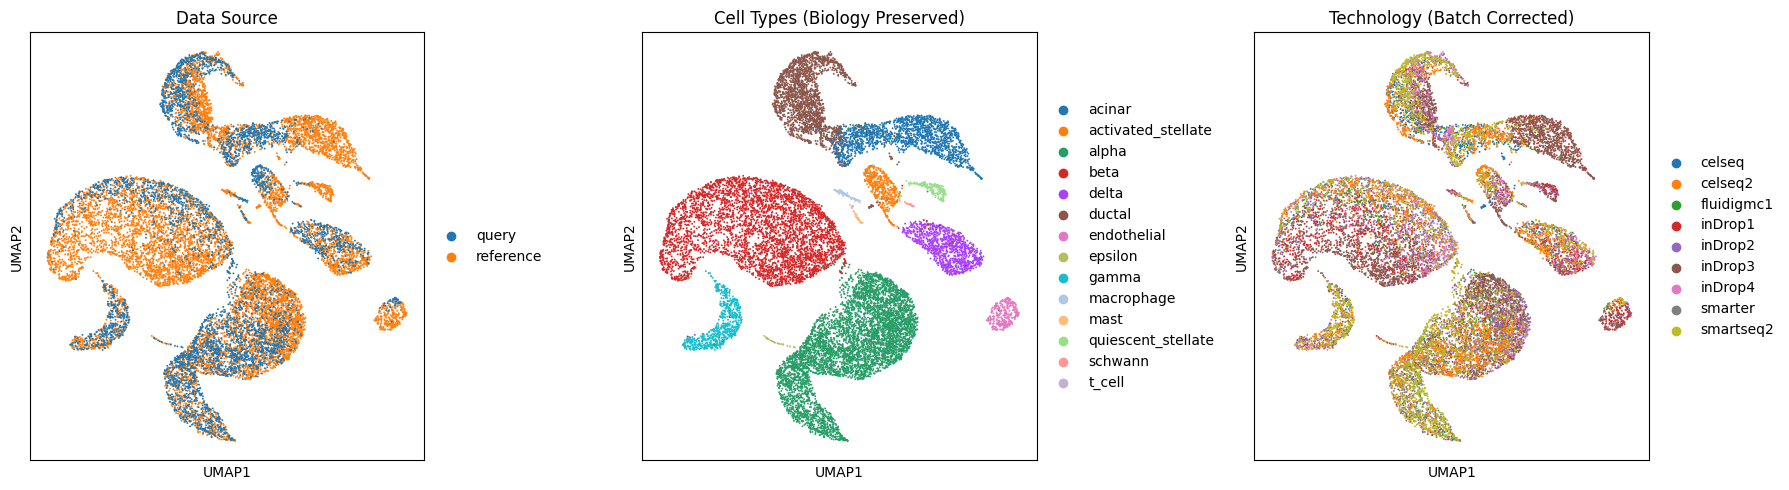

In [7]:
adata_ref_corrected.obs['source'] = 'reference'
adata_query_corrected.obs['source'] = 'query'

adata_ref_query = ad.concat([adata_ref_corrected, adata_query_corrected], join='inner', merge='same')
adata_ref_query.obs_names_make_unique()

sc.pp.neighbors(adata_ref_query, use_rep='X_ScAdver', n_neighbors=15)
sc.tl.umap(adata_ref_query, random_state=SEED)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sc.pl.umap(adata_ref_query, color='source', ax=axes[0], show=False, title='Data Source')
sc.pl.umap(adata_ref_query, color=bio_label, ax=axes[1], show=False, title='Cell Types (Biology Preserved)')
sc.pl.umap(adata_ref_query, color=batch_label, ax=axes[2], show=False, title='Technology (Batch Corrected)')
plt.tight_layout()
plt.show()

In [8]:
adata_ref_query

AnnData object with n_obs × n_vars = 16382 × 2000
    obs: 'tech', 'celltype', 'size_factors', 'source'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'neighbors', 'umap', 'source_colors', 'celltype_colors', 'tech_colors'
    obsm: 'X_ScAdver', 'X_umap'
    layers: 'counts', 'ScAdver_reconstructed'
    obsp: 'distances', 'connectivities'

In [9]:
# For downstream analysis, you can use the reconstructed data (if returned) or the original data with the new embedding.
adata_downstream = adata_ref_query.copy()
adata_downstream.X = adata_downstream.layers['ScAdver_reconstructed'].copy()